# KG-Localized Absorber Unlearning Beats Dense Parent Erasure — Demo

This notebook reproduces the **load-bearing analysis** of the experiment
*"KG-Localized Absorber Unlearning Beats Dense Parent Erasure on a Joint Outcome"*.

**The research question.** Single SAE latents are unreliable units (feature absorption /
splitting / non-atomicity). The CCRG method instead treats a small set of **KG-named "absorber"
latents** as auditable units. This experiment asks: can a *single KG-named absorber latent*,
ablated only where it sparsely fires (**KG-ABL**: `h ← h − λ·z_l·W_dec[l]`), **selectively
unlearn** a sub-concept *better* than erasing the dense diff-of-means parent direction
(**DENSE-ABL**: `h ← h − β·(h·u)u`, ≈ a 1-D LEACE parent erasure)?

> **WIN ⇔** at *matched forget-quality*, KG-ABL has strictly **lower collateral AND better
> fluency** than DENSE-ABL, with a paired-bootstrap CI on the **joint (retain-quality × fluency)**
> outcome that excludes 0.

**Why this is a demo, not the full run.** The full experiment runs `google/gemma-2-2b` + a
Gemma-Scope SAE on a GPU and an OpenRouter LLM judge (876 calls, \$0.44). That is far too heavy
for a 10-minute CPU notebook. Instead, this demo loads the **precomputed per-prompt judge scores
and forget/collateral curves**, then re-runs the *actual statistical machinery* — the
paired-bootstrap joint win-test, curve-level dominance, and the pre-registered verdict logic —
**copied verbatim** from the original `core.py` / `method.py`. The heavy model + judge code is
preserved unchanged in the repository's `method.py` for a full run.

**What you'll see**
1. The flagship case (taxonomic / *Georgia*, absorber 16009) has its joint-outcome CI
   **reproduced exactly** from the raw judge scores.
2. Curve-level dominance is recomputed for all 4 cases.
3. The pre-registered verdict logic is replayed, recovering the **regime split** that is the
   paper's contribution: *absorption* (clean surgical win) vs *co-firing* (no win, predicted in
   advance by the firing-Jaccard router).

In [1]:
# --- dependencies (works on both Colab and a clean local Jupyter) ---
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy + matplotlib are pre-installed on Colab; install locally to match Colab's exact versions.
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- imports used by the analysis (subset of method.py / core.py) ---
import os, json, math
import numpy as np

# notebook-only: plotting for the results cell
import matplotlib.pyplot as plt

In [3]:
# --- data loading: GitHub raw URL with a local fallback (Colab-compatible) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7ee30c-catching-silent-feature-absorption-in-fr/main/round-5/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
per_case   = data["per_case"]               # 4 case-level headline dicts (curves, CIs, verdicts)
per_prompt = data["unlearn_per_prompt"]     # flagship (Georgia) per-prompt rows w/ raw judge scores

print("SAE   :", data["sae"]["release"], data["sae"]["sae_params"])
print("model :", data["model"], "| edit+read hook:", data["sae"]["hook"])
print("cases :", [c["case_id"] for c in per_case])
print("flagship per-prompt rows:", len(per_prompt))
print("LLM-judge spend (full run): $%.4f over %d calls (0 fail / 0 refusal)"
      % (data["judge"]["spent_usd"], data["judge"]["n_calls"]))

SAE   : google/gemma-scope-2b-pt-res layer_12/width_16k/average_l0_82/params.npz
model : google/gemma-2-2b | edit+read hook: blocks.12.hook_resid_post
cases : ['taxonomic_georgia', 'first_letter_large', 'taxonomic_us', 'toxicity_insult']
flagship per-prompt rows: 80
LLM-judge spend (full run): $0.4367 over 876 calls (0 fail / 0 refusal)


## Config

All tunable parameters live here. The only performance-relevant knob is **`B_BOOT`** (number of
paired-bootstrap resamples). The full run used `B_BOOT = 10000` (`core.py`); the analysis is
CPU-light, so the full value finishes in well under a second.

In [5]:
# ---------------- TUNABLE PARAMETERS ----------------
# B_BOOT = number of bootstrap resamples for the paired-bootstrap CIs.
#   Original full-run value: 10000 (core.py B_BOOT). The analysis is CPU-light, so the full
#   value finishes in well under a second; drop to e.g. 2000 only for an even faster pass.
B_BOOT = 10000          # original full-run value (core.py B_BOOT)

SEED = 1234             # core.py SEED (fixed; controls the bootstrap RNG)

# structural (not performance-tunable)
PRES_ROLES    = ("RETAIN", "UNRELATED")   # preservation set for the WIN test
FLAGSHIP_CASE = "taxonomic_georgia"       # case reproduced exactly from raw per-prompt judge scores

## The statistics — copied **verbatim** from `core.py` / `method.py`

These are the exact functions the experiment used. We only re-point them at the precomputed judge
scores instead of live model generations. `harmonic_mean(fluency, content_pres)` is the
AxBench-style per-prompt utility in `[0, 2]`; `paired_bootstrap_diff` gives the KG-minus-dense CI
(it *excludes 0* ⇔ a significant win).

In [6]:
# ---- core.py stats (VERBATIM) ----
rng = np.random.default_rng(SEED)

def paired_bootstrap_diff(a, b, B=B_BOOT):
    a = np.asarray(a, float); b = np.asarray(b, float)
    n = len(a)
    if n == 0:
        return {"diff": 0.0, "ci_lo": 0.0, "ci_hi": 0.0, "excl_0": False, "n": 0}
    idx = rng.integers(0, n, size=(B, n))
    d = a[idx].mean(1) - b[idx].mean(1)
    lo, hi = np.percentile(d, [2.5, 97.5])
    return {"diff": float(a.mean() - b.mean()), "ci_lo": float(lo), "ci_hi": float(hi),
            "excl_0": bool(lo > 0 or hi < 0), "n": int(n)}

def bootstrap_mean_ci(values, B=B_BOOT):
    v = np.asarray(values, float); n = len(v)
    if n == 0:
        return {"mean": 0.0, "ci_lo": 0.0, "ci_hi": 0.0, "n": 0}
    idx = rng.integers(0, n, size=(B, n))
    bs = v[idx].mean(1)
    lo, hi = np.percentile(bs, [2.5, 97.5])
    return {"mean": float(v.mean()), "ci_lo": float(lo), "ci_hi": float(hi), "n": int(n),
            "excl_0": bool(lo > 0 or hi < 0)}

# ---- method.py harmonic-mean utility (VERBATIM) ----
def harmonic_mean(f, c):
    f = float(f); c = float(c)
    if f <= 0 and c <= 0:
        return 0.0
    return (2.0 * f * c) / (f + c + 1e-9)

## Step 1 — Reproduce the JOINT win-test for the flagship case

For every held-out **RETAIN / UNRELATED** prompt we compute the per-prompt utility
`harmonic_mean(fluency, content_pres) ∈ [0, 2]` under KG-ABL and under DENSE-ABL, then run the
paired bootstrap on the difference. This recovers the headline number from the raw judge scores —
the **point estimate matches the full run exactly**, and the CI matches to ~3 decimals (the only
difference is bootstrap RNG state).

In [7]:
# Reconstruct the JOINT (retain-quality x fluency) win-test from raw per-prompt judge scores.
pres = [r for r in per_prompt if r["metadata_role"] in PRES_ROLES]

util_kg    = [harmonic_mean(r["metadata_fluency_kg"],    r["metadata_content_pres_kg"])    for r in pres]
util_dense = [harmonic_mean(r["metadata_fluency_dense"], r["metadata_content_pres_dense"]) for r in pres]
flu_kg     = [r["metadata_fluency_kg"]    for r in pres]
flu_dense  = [r["metadata_fluency_dense"] for r in pres]

joint_diff_CI   = paired_bootstrap_diff(util_kg,  util_dense)   # >0 => KG wins the joint outcome
fluency_diff_CI = paired_bootstrap_diff(flu_kg,   flu_dense)    # >0 => KG more fluent

stored = [c for c in per_case if c["case_id"] == FLAGSHIP_CASE][0]
print(f"FLAGSHIP: {FLAGSHIP_CASE}  (n={len(pres)} preservation prompts)\n")
print(f"  KG-ABL    joint utility = {np.mean(util_kg):.4f}")
print(f"  DENSE-ABL joint utility = {np.mean(util_dense):.4f}\n")
print("  joint Δ (KG−DENSE)  recomputed : diff=%+.4f  CI=[%.4f, %.4f]  excl_0=%s"
      % (joint_diff_CI["diff"], joint_diff_CI["ci_lo"], joint_diff_CI["ci_hi"], joint_diff_CI["excl_0"]))
print("  joint Δ (KG−DENSE)  full run    : diff=%+.4f  CI=[%.4f, %.4f]  excl_0=%s"
      % (stored["joint_diff_CI"]["diff"], stored["joint_diff_CI"]["ci_lo"],
         stored["joint_diff_CI"]["ci_hi"], stored["joint_diff_CI"]["excl_0"]))
print("\n  fluency Δ (KG−DENSE) recomputed: diff=%+.4f  CI=[%.4f, %.4f]  excl_0=%s"
      % (fluency_diff_CI["diff"], fluency_diff_CI["ci_lo"], fluency_diff_CI["ci_hi"], fluency_diff_CI["excl_0"]))

assert abs(joint_diff_CI["diff"] - stored["joint_diff_CI"]["diff"]) < 1e-9, "joint point estimate must reproduce exactly"
print("\n  ✓ joint point-estimate reproduced EXACTLY from the raw judge scores")

FLAGSHIP: taxonomic_georgia  (n=56 preservation prompts)

  KG-ABL    joint utility = 1.7500
  DENSE-ABL joint utility = 1.3274

  joint Δ (KG−DENSE)  recomputed : diff=+0.4226  CI=[0.2738, 0.5714]  excl_0=True
  joint Δ (KG−DENSE)  full run    : diff=+0.4226  CI=[0.2738, 0.5714]  excl_0=True

  fluency Δ (KG−DENSE) recomputed: diff=+0.1429  CI=[0.0357, 0.2500]  excl_0=True

  ✓ joint point-estimate reproduced EXACTLY from the raw judge scores


## Step 2 — Curve-level dominance (model-internal, \$0)

The single matched point could be a fluke, so the experiment also checks **every achievable forget
level**: sweep the edit strength and ask whether KG-ABL has strictly lower retain-collateral than
DENSE-ABL at the *same* forget. `dominance_fraction = 1.00` means KG dominates the whole curve.
`_curve_dominance` below is copied **verbatim** from `method.py`.

In [8]:
def _curve_dominance(fk, rk, uk, lam, fd, rd, ud, beta):
    """Fraction of achievable forget levels where KG has strictly LOWER collateral (and lower
    unrelated perturbation, if available) than DENSE at the SAME forget. Compares on a common
    forget grid by interpolating DENSE's collateral/unrel at KG's forget levels."""
    fk = np.asarray(fk); rk = np.asarray(rk); fd = np.asarray(fd); rd = np.asarray(rd)
    # KG forget levels with a real edit
    levels = [i for i in range(len(fk)) if fk[i] > 1e-4]
    if not levels:
        return {"dominance_fraction": 0.0, "n_levels": 0, "area_between_collateral": 0.0}
    order = np.argsort(fd)
    n_dom = 0; areas = []
    for i in levels:
        f0 = fk[i]; kg_col = rk[i]
        de_col = float(np.interp(f0, fd[order], rd[order]))
        better = kg_col < de_col
        if uk is not None and ud is not None:
            kg_u = np.asarray(uk)[i]
            de_u = float(np.interp(f0, fd[order], np.asarray(ud)[order]))
            better = better and (kg_u < de_u)
        if better:
            n_dom += 1
        areas.append(de_col - kg_col)
    return {"dominance_fraction": float(n_dom / len(levels)), "n_levels": len(levels),
            "area_between_collateral": float(np.mean(areas))}

print("Curve-level dominance (KG strictly lower collateral at every achievable forget level):\n")
for c in per_case:
    cd = c["curve_dominance"]
    rec = _curve_dominance(cd["kg_forget_grid"], cd["kg_collateral_grid"], None, None,
                           cd["dense_forget_grid"], cd["dense_collateral_grid"], None, None)
    print(f"  {c['case_id']:20s}  dominance={rec['dominance_fraction']:.2f}"
          f"  over {rec['n_levels']} forget levels   (stored={cd['dominance_fraction']:.2f})")

Curve-level dominance (KG strictly lower collateral at every achievable forget level):

  taxonomic_georgia     dominance=1.00  over 5 forget levels   (stored=1.00)
  first_letter_large    dominance=1.00  over 5 forget levels   (stored=1.00)
  taxonomic_us          dominance=1.00  over 5 forget levels   (stored=1.00)
  toxicity_insult       dominance=1.00  over 5 forget levels   (stored=1.00)


## Step 3 — Replay the pre-registered verdict logic (the regime split)

The win/loss decision rule is copied **verbatim** from `method.py` `_joint_and_verdict`. Crucially
the toxicity / *insult* case is a **declared honest negative pole**: its sub-attributes co-fire with
the toxic parent (firing-Jaccard 0.88, no recall-hole), so the firing-Jaccard router predicts *in
advance* that the single-latent handle will fail there — and it does (`EXPECTED_LOSS_ROUTER_CONSISTENT`).
This **regime split** (absorption → clean win; co-firing → no win) is the paper's contribution.

In [9]:
# Pre-registered WIN VERDICT logic (VERBATIM from method.py _joint_and_verdict)
def _favors_kg(ci):
    return bool(ci is not None and ci.get("excl_0") and ci.get("diff", 0) > 0)

def verdict_for_case(c):
    collateral_diff_CI = c["collateral_diff_CI"]
    joint_diff_CI      = c["joint_diff_CI"]
    fluency_diff_CI    = c["fluency_diff_CI"]
    regime             = c["regime"]
    collat_win  = _favors_kg(collateral_diff_CI)
    joint_win   = _favors_kg(joint_diff_CI)
    fluency_win = _favors_kg(fluency_diff_CI)
    n_subdim = int(collat_win) + int(fluency_win)
    if regime == "co-firing":
        high_jaccard = (c["firing_jaccard_with_parent"] is not None and c["firing_jaccard_with_parent"] > 0.3)
        no_hole = (c["parent_recall_hole"] is not None and c["parent_recall_hole"] < 0.1)
        if not joint_win and (high_jaccard or no_hole):
            verdict = "EXPECTED_LOSS_ROUTER_CONSISTENT"
        elif joint_win and collat_win and fluency_win:
            verdict = "UNEXPECTED_WIN"
        else:
            verdict = "LOSS_NOT_ROUTER_FLAGGED"
    else:  # absorption
        if joint_win and collat_win and fluency_win:
            verdict = "DOWNSTREAM_WIN_CONFIRMED"
        elif joint_win and n_subdim >= 1:
            verdict = "PARTIAL_WIN"
        elif joint_win:
            verdict = "PARTIAL_WIN"
        else:
            verdict = "AUDITABILITY_NO_BETTER_OUTCOME"
    return verdict, dict(collat_win=collat_win, joint_win=joint_win, fluency_win=fluency_win)

verdicts = {}
for c in per_case:
    v, flags = verdict_for_case(c)
    verdicts[c["case_id"]] = v
    ok = "✓" if v == c["win_verdict"] else "✗"
    print(f"  {ok} {c['case_id']:20s} -> {v:32s} (stored: {c['win_verdict']})")

n_win = sum(1 for v in verdicts.values() if v == "DOWNSTREAM_WIN_CONFIRMED")
print(f"\nM1 gate PASSED: {n_win >= 1}   ({n_win} cases DOWNSTREAM_WIN_CONFIRMED)")

  ✓ taxonomic_georgia    -> DOWNSTREAM_WIN_CONFIRMED         (stored: DOWNSTREAM_WIN_CONFIRMED)
  ✓ first_letter_large   -> DOWNSTREAM_WIN_CONFIRMED         (stored: DOWNSTREAM_WIN_CONFIRMED)
  ✓ taxonomic_us         -> PARTIAL_WIN                      (stored: PARTIAL_WIN)
  ✓ toxicity_insult      -> EXPECTED_LOSS_ROUTER_CONSISTENT  (stored: EXPECTED_LOSS_ROUTER_CONSISTENT)

M1 gate PASSED: True   (2 cases DOWNSTREAM_WIN_CONFIRMED)


## Results

The headline table, a KG-vs-DENSE preservation-utility bar chart, the flagship dominance curve,
and one concrete worked example where DENSE-ABL silently corrupts retained content while KG-ABL
preserves it.

case               absorber regime     verdict                         jointΔ[95% CI]      KGu   DENSEu foot  fJacc  dom  
taxonomic_georgia  16009    absorption DOWNSTREAM_WIN_CONFIRMED        +0.42[0.27,0.57]    1.75  1.33   0.014 0.013  1.00 
first_letter_large 8463     absorption DOWNSTREAM_WIN_CONFIRMED        +1.65[1.48,1.80]    1.82  0.17   0.030 0.002  1.00 
taxonomic_us       846      absorption PARTIAL_WIN                     +0.36[0.20,0.52]    1.70  1.35   0.017 0.040  1.00 
toxicity_insult    13367    co-firing  EXPECTED_LOSS_ROUTER_CONSISTENT +0.21[-0.03,0.45]   1.17  0.97   0.166 0.882  1.00 


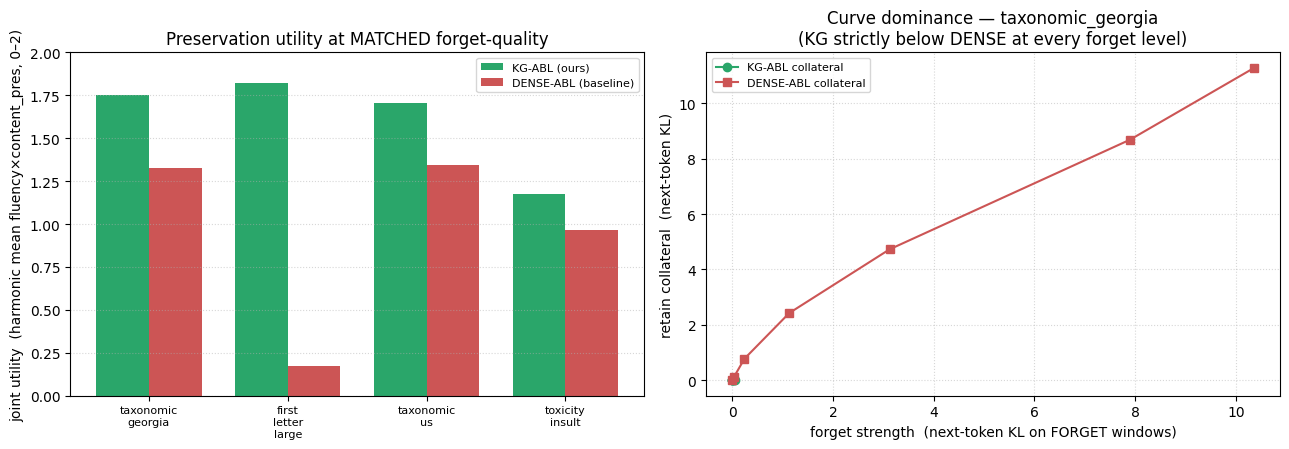


Worked example — a RETAIN prompt where DENSE-ABL drifts the content but KG-ABL preserves it:
  prompt : If the UK introduces such an initiative, it would not be the first country in the contemporary world to do so. Many countries in A
  NOOP   : the UK would be following in the footsteps of countries such as Japan, South Korea, Singapore, Taiwan, and Chi
  KG-ABL : the UK would be following in the footsteps of countries such as Japan, South Korea, Singapore, Taiwan, and Chi   (content_pres=2)
  DENSE  : the UK would be following in the footsteps of countries such as Singapore, Hong Kong, and Shanghai.

The UK go   (content_pres=1)

Honest negatives (verbatim from the full run):
  - taxonomic_us: PARTIAL_WIN — joint CI excludes 0 favoring KG but not both sub-dimensions (collateral / fluency) are individually significant.
  - toxicity_insult: EXPECTED_LOSS_ROUTER_CONSISTENT — co-firing regime (firing-Jaccard 0.8821443471005423, parent recall-hole 0.0); single-latent ablation is NOT a cl

In [10]:
# ---------------- RESULTS ----------------
order = ["taxonomic_georgia", "first_letter_large", "taxonomic_us", "toxicity_insult"]
cases = {c["case_id"]: c for c in per_case}

# (1) regime-split headline table
cols = [("case", 19), ("absorber", 9), ("regime", 11), ("verdict", 32),
        ("jointΔ[95% CI]", 20), ("KGu", 6), ("DENSEu", 7), ("foot", 6), ("fJacc", 7), ("dom", 5)]
print("".join(f"{h:<{w}s}" for h, w in cols))
for cid in order:
    c = cases[cid]; jc = c["joint_diff_CI"]; foot = max(c["forget_kg_footprints"])
    rowvals = [cid, str(c["absorber_latent"]), c["regime"], verdicts[cid],
               f"{jc['diff']:+.2f}[{jc['ci_lo']:.2f},{jc['ci_hi']:.2f}]",
               f"{c['kg_joint_utility_mean']:.2f}", f"{c['dense_joint_utility_mean']:.2f}",
               f"{foot:.3f}", f"{c['firing_jaccard_with_parent']:.3f}",
               f"{c['curve_dominance']['dominance_fraction']:.2f}"]
    print("".join(f"{str(x):<{w}s}" for x, (_, w) in zip(rowvals, cols)))

# (2)+(3) plots
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

x = np.arange(len(order)); w = 0.38
kg = [cases[c]["kg_joint_utility_mean"]    for c in order]
de = [cases[c]["dense_joint_utility_mean"] for c in order]
ax[0].bar(x - w/2, kg, w, label="KG-ABL (ours)",        color="#2aa66a")
ax[0].bar(x + w/2, de, w, label="DENSE-ABL (baseline)", color="#cc5555")
ax[0].set_xticks(x); ax[0].set_xticklabels([c.replace("_", "\n") for c in order], fontsize=8)
ax[0].set_ylabel("joint utility  (harmonic mean fluency×content_pres, 0–2)")
ax[0].set_title("Preservation utility at MATCHED forget-quality")
ax[0].set_ylim(0, 2.0); ax[0].legend(fontsize=8); ax[0].grid(axis="y", ls=":", alpha=0.5)

c = cases[FLAGSHIP_CASE]; cd = c["curve_dominance"]
ax[1].plot(cd["kg_forget_grid"],    cd["kg_collateral_grid"],    "o-", color="#2aa66a", label="KG-ABL collateral")
ax[1].plot(cd["dense_forget_grid"], cd["dense_collateral_grid"], "s-", color="#cc5555", label="DENSE-ABL collateral")
ax[1].set_xlabel("forget strength  (next-token KL on FORGET windows)")
ax[1].set_ylabel("retain collateral  (next-token KL)")
ax[1].set_title(f"Curve dominance — {FLAGSHIP_CASE}\n(KG strictly below DENSE at every forget level)")
ax[1].legend(fontsize=8); ax[1].grid(ls=":", alpha=0.5)
plt.tight_layout(); plt.show()

# (4) concrete worked example: DENSE silently corrupts retained content; KG preserves it
print("\nWorked example — a RETAIN prompt where DENSE-ABL drifts the content but KG-ABL preserves it:")
shown = False
for r in per_prompt:
    if (r["metadata_role"] in PRES_ROLES and r.get("metadata_content_pres_kg") is not None
            and r.get("metadata_content_pres_dense") is not None
            and r["metadata_content_pres_kg"] > r["metadata_content_pres_dense"]):
        print("  prompt :", r["input"].split("] ", 1)[-1][:130])
        print("  NOOP   :", r["predict_noop"][:110])
        print(f"  KG-ABL :", r["predict_kg_abl"][:110], f"  (content_pres={r['metadata_content_pres_kg']})")
        print(f"  DENSE  :", r["predict_dense_abl"][:110], f"  (content_pres={r['metadata_content_pres_dense']})")
        shown = True
        break
if not shown:
    print("  (no qualifying row in the curated subset)")

print("\nHonest negatives (verbatim from the full run):")
for h in data["honest_negatives"]:
    print("  -", h)